💻 Tarefa 1 - Atividade Computacional  
## Regressão Linear Simples &nbsp;·&nbsp; Gastos em TV & Vendas

---

📊 **Valor: 10 pontos**

📅 **Data de Entrega: 17/08/2026 às 23h59m**

---

---
## 📺 1. Conhecendo o Dataset — *Advertising*

### Contexto Real

O dataset **Advertising** é um dos mais utilizados em cursos de Machine Learning e Estatística no mundo. Foi publicado no livro **"An Introduction to Statistical Learning" (ISLR)** de James, Witten, Hastie e Tibshirani (2013) — referência mundial no ensino de ML.

Ele representa dados de **200 mercados** diferentes nos EUA. Para cada mercado, registrou-se o **investimento em publicidade** (em milhares de dólares) em três mídias e o **volume de vendas** de um produto:

### 📐 Dicionário de Variáveis

| Variável | Tipo | Descrição | Unidade |
|----------|------|-----------|---------|
| `TV` | Numérica | Investimento em publicidade na TV | Mil dólares (US\$k)|
| `Radio` | Numérica | Investimento em rádio | Mil dólares (US$k) |
| `Newspaper` | Numérica | Investimento em jornal | Mil dólares (US\$k) |
| `Sales` | **Target 🎯** | Volume de vendas do produto | Mil unidades |


### 🎯 Problema

> **Pergunta de negócio:** _"Se uma empresa investir R$ X em publicidade na TV, quantas unidades do produto ela pode esperar vender?"_
>
> Nesta tarefa usaremos **regressão linear simples** com `TV` como preditor de `Sales`.

# 1. Carregamento do banco de dados

O arquivo será carregado diretamente de um repositório público, e armazenado em variável chamada `df` do tipo DataFrame.


In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/nguyen-toan/ISLR/refs/heads/master/dataset/Advertising.csv"

df = pd.read_csv(url)

df.head(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


---
## 🔍 2. Análise Exploratória e Insights

Antes de modelar, é fundamental **conhecer os dados profundamente**. Veja a seguir os principais insights do dataset Advertising.

Ao utilizar o método .head(), observa que a primeira coluna `Unnamed: 0` corresponde ao indices, portanto pode ser excluida pelo método `.drop`

In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True) #retirar a coluna ''Unnamed: 0'
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## ✏️ Exercício 1 (2 pontos)— Inspeção Inicial do Dataset

**Enunciado:**

Realize a inspeção inicial do DataFrame `df`:

-  Utilizar o método `.head()` para exibir as primeiras 5 linhas do dataset
-  Utilizar o método `.shape` para verificar a quantidade de **linhas (amostras)** e **colunas (variáveis)** presentes no banco de dados.
-   Utilizar o método `.info()` para obter detalhes sobre os tipos de variáveis (numéricas ou categóricas), valores nulos e estrutura geral do dataset.
- Utilizar o método `.describe()` para visualizar estatísticas básicas como **média, desvio padrão, valores mínimos e máximos**, ajudando a compreender a distribuição dos dados.

<details>
<summary><strong>▶ Abrir exemplo de possível aplicação</strong></summary>

Imagine um DataFrame chamado `turma`, com as colunas `Horas_estudo`, `Faltas` e `Nota`.

```python
display(turma.head())
print(turma.shape)
turma.info()
display(turma.describe())
```

Esse procedimento permite conhecer rapidamente o tamanho, a estrutura e a distribuição dos dados antes de iniciar uma análise.

</details>


In [14]:
#Resposta Exercício 1
df.head(5)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [15]:
df.shape


(200, 4)

In [16]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## ✏️ Exercício 2 (2 pontos) — Correlação e Scatterplot TV × Sales

**Enunciado:**

1. Calcule a **correlação de Pearson** entre `TV` e `Sales`.
2. Crie um **scatterplot** de `TV` × `Sales`

**💡 Dica:** `df['TV'].corr(df['Sales'])` retorna o coeficiente r de Pearson.

<details>
<summary><strong>▶ Abrir exemplo de possível aplicação</strong></summary>

Em uma escola, pode-se analisar a relação entre `Horas_estudo` e `Nota`.

```python
correlacao = dados["Horas_estudo"].corr(dados["Nota"])
print(correlacao)

plt.scatter(dados["Horas_estudo"], dados["Nota"])
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.title("Horas de estudo × Nota")
plt.show()
```

Uma nuvem de pontos crescente sugere relação positiva; uma nuvem decrescente sugere relação negativa.

</details>


In [18]:
#resposta do exercício 2

# Aqui temos o overview, porém, a correlação que interessa é a próxima
df[['TV', 'Sales']].corr()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


In [20]:
# A corelação é positiva e próxima de 1 e isso indica que quando X aumenta, a inclinação da reta tende a aumentar
# Se fosse zero, não haveria correlação nenhuma entre as variáveis.

df[['TV', 'Sales']].corr().loc['TV', 'Sales']

np.float64(0.7822244248616067)

In [23]:
# Esse forma fornece a correlação, ela é melhor e mais direta. A ideia é mesma usando loc. Ela é preferível.
df["TV"].corr(df["Sales"])


np.float64(0.7822244248616061)

Text(0.5, 1.0, 'TV × Sales')

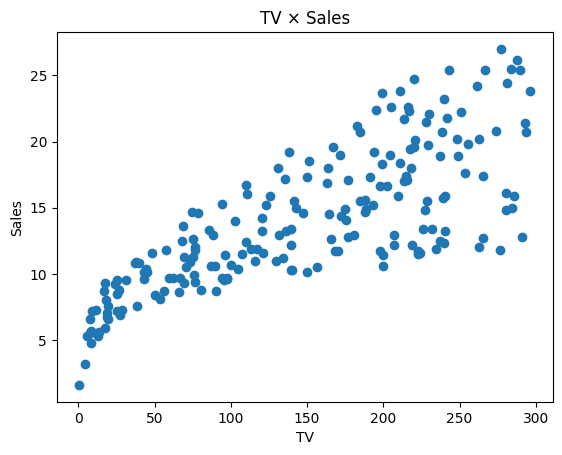

In [36]:
import matplotlib.pyplot as plt


plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV × Sales")


## ✏️ Exercício 3 (2 pontos) — Preparação dos Dados

**Enunciado:**

1. Defina `X` como a coluna `TV` **em formato 2D** e `y` como `Sales`.
2. Divida os dados em **80% treino e 20% teste** com `random_state=42` (a função `train_test_split` do `sklearn.model_selection` para divisão dos dado e ajustar o parâmetro `test_size`).
3. Imprima o tamanho de cada conjunto e confirme que somam 200.


**💡 Conceito:** Por que `X` precisa ser 2D?
> O scikit-learn espera que as features sejam uma **matriz** (linhas × colunas). Para uma única feature, use `df[['TV']]` (duplos colchetes) que retorna shape `(200, 1)`, não `(200,)`.


<details>
<summary><strong>▶ Abrir exemplo de possível aplicação</strong></summary>

Para prever o consumo de energia a partir da temperatura:

```python
X = dados[["Temperatura"]]
y = dados["Consumo"]

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_treino.shape, X_teste.shape)
print(y_treino.shape, y_teste.shape)
```


</details>

#  Definição de `X` e `y`

```python
X = df[["TV"]]
y = df["Sales"]
```

### `X = df[["TV"]]`

O `X` representa a **variável de entrada (feature)** que será usada pelo modelo para fazer a previsão.

```python
df[["TV"]]
```

As **duas colchetes `[[ ]]`** fazem com que a coluna `TV` seja retornada como uma **matriz 2D**.

Nesse caso, temos:

```text
200 registros × 1 coluna
```

Ou seja:

```text
(200, 1)
```

Isso é importante porque o **Scikit-Learn espera que `X` esteja no formato 2D**, mesmo quando temos apenas uma variável de entrada.

Podemos visualizar assim:

```text
X
┌───────┐
│  TV   │
├───────┤
│ 230.1 │
│  44.5 │
│  17.2 │
│ 151.5 │
│ 180.8 │
│  ...  │
│  ...  │
└───────┘
  200 linhas
  1 coluna
```

Portanto:

```python
X = df[["TV"]]
```

significa:

> Pegue a coluna `TV` mantendo-a no formato de uma matriz 2D.

---

### `y = df["Sales"]`

Já o `y` representa a **variável de saída (target)**, ou seja, aquilo que queremos que o modelo aprenda a prever.

```python
y = df["Sales"]
```

Aqui usamos apenas **uma colchete `[ ]`** porque queremos uma **Series do Pandas**, e não uma matriz 2D.

O formato será:

```text
(200,)
```

Podemos imaginar:

```text
y
┌───────┐
│ Sales │
├───────┤
│  22.1 │
│  10.4 │
│   9.3 │
│  18.5 │
│  21.2 │
│  ...  │
│  ...  │
└───────┘
  200 valores
```

O `y` é uma única variável que queremos prever, por isso normalmente é representado como um vetor/Series de uma dimensão.

---

## Por que `X` tem `[[ ]]` e `y` tem `[ ]`?

A diferença pode ser resumida assim:

| Código          | Resultado |   Dimensão | Função           |
| --------------- | --------- | ---------: | ---------------- |
| `df["TV"]`      | Series    |   `(200,)` | Uma coluna em 1D |
| `df[["TV"]]`    | DataFrame | `(200, 1)` | Uma coluna em 2D |
| `df["Sales"]`   | Series    |   `(200,)` | Target em 1D     |
| `df[["Sales"]]` | DataFrame | `(200, 1)` | Target em 2D     |

Para este exercício:

```python
X = df[["TV"]]
y = df["Sales"]
```

Temos:

```text
X → variável de entrada → 2D → (200, 1)
y → variável que queremos prever → 1D → (200,)
```

### Regra prática

Uma forma simples de lembrar:

> **`X` → use `[[ ]]` porque o Scikit-Learn espera as features em formato 2D.**

> **`y` → use `[ ]` porque estamos trabalhando com uma única variável que queremos prever.**


In [ ]:
#resposta do exercício 3

# X = variáveis de entrada (features) - o que o modelo usa para fazer previsões
# Usamos df[["TV"]] com DOIS colchetes para retornar um DataFrame 2D (matriz)
# O scikit-learn espera que X tenha formato (n_amostras, n_features)
# Neste caso: (200, 1) → 200 mercados, 1 feature (investimento em TV)
X = df[["TV"]]

# y = variável alvo (target) - o que queremos prever
# Usamos df["Sales"] com UM colchete para retornar uma Series 1D (vetor)
# y tem formato (200,) → 200 valores de vendas correspondentes
y = df["Sales"]  # O y representa uma única variável que queremos prever, por isso não está em matriz

In [40]:
df[["TV"]] # Formato que scikit-learn espera, representa o numero de registro(200) em 1 coluna, isso é uma matriz 2D(200 linhas x 1 coluna)


,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8
...,...
195,38.2
196,94.2
197,177.0
198,283.6


In [ ]:
# Verificando as dimensões de X (variável de entrada - TV)
# X deve ser 2D (matriz) porque o scikit-learn espera: (n_amostras, n_features)
# Como temos apenas 1 feature (TV), o shape será (200, 1)
# 200 linhas (amostras) e 1 coluna (feature)
print("Shape de X (variável de entrada):", X.shape)
print(f"  → {X.shape[0]} amostras (mercados)")
print(f"  → {X.shape[1]} feature (investimento em TV)")
print("\nPrimeiras 5 linhas de X:")
print(X.head())

In [ ]:
# Verificando as dimensões de y (variável alvo - Sales)
# y é um vetor 1D (Series do Pandas) porque representa uma única variável
# Shape será (200,) → 200 valores de vendas
print("Shape de y (variável alvo):", y.shape)
print(f"  → {y.shape[0]} valores alvo (vendas em mil unidades)")
print(f"  → Formato 1D (vetor), não precisa ser matriz")
print("\nPrimeiros 5 valores de y:")
print(y.head())

## ✏️ Exercício 4 (2 pontos) — Treinar o Modelo `LinearRegression`

**Enunciado:**

1. **Instancie** o modelo `LinearRegression()` da biblioteca `sklearn.linear_model`  
2. **Treine** o modelo com os dados de treino usando `.fit(X_train, y_train)`.

<details>
<summary><strong>▶ Abrir exemplo de possível aplicação</strong></summary>

Um modelo poderia aprender a prever a nota de um aluno com base nas horas de estudo:

```python
from sklearn.linear_model import LinearRegression

modelo_exemplo = LinearRegression()
modelo_exemplo.fit(X_treino, y_treino)

print("Modelo treinado!")
```

O método `.fit()` corresponde ao momento em que o modelo aprende a relação entre entrada e saída.

</details>


In [ ]:
#resposta do exercício 4

# Importando o modelo LinearRegression da biblioteca scikit-learn
# Este é o modelo de Regressão Linear que aprende uma relação linear entre X e y
# A equação aprendida será: y = θ₀ + θ₁×X (reta: intercepto + coeficiente * feature)
from sklearn.linear_model import LinearRegression

# Importando train_test_split para dividir os dados em treino e teste
# Isso é essencial para avaliar se o modelo generaliza bem para dados não vistos
from sklearn.model_selection import train_test_split

In [ ]:
# Dividindo os dados em conjunto de TREINO e TESTE
# Esta é uma prática fundamental em Machine Learning para avaliar a generalização do modelo

# X = dados de entrada (investimentos em TV)
# y = dados de saída/vendas que queremos prever
# test_size=0.2 significa que 20% dos dados serão separados para teste (40 amostras)
# random_state=42 garante que a divisão será sempre a mesma toda vez que rodar o código
# Isso permite reprodutibilidade dos resultados

X_train, X_test, y_train, y_test = train_test_split(
    X,              # DataFrame com a feature TV (200 amostras, 1 feature)
    y,              # Series com o target Sales (200 valores)
    test_size=0.2,  # 20% para teste = 40 amostras | 80% para treino = 160 amostras
    random_state=42 # Semente aleatória fixa para reprodutibilidade
)

# O que cada variável contém:
# X_train → Dados de TREINO da feature TV (160 amostras)
# X_test  → Dados de TESTE da feature TV (40 amostras)
# y_train → Valores reais de TREINO do target Sales (160 valores)
# y_test  → Valores reais de TESTE do target Sales (40 valores)

In [55]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160, 1)
X_test : (40, 1)
y_train: (160,)
y_test : (40,)


In [56]:
print(len(X_train) + len(X_test))

200


In [ ]:
# Criando uma instância do modelo LinearRegression
# Neste ponto, o modelo ainda não aprendeu nada - é apenas uma "estrutura vazia"
# model = LinearRegression() cria o objeto com os hiperparâmetros padrão
# - fit_intercept=True (padrão): o modelo aprende o intercepto (θ₀)
# - normalize=False (padrão): não normaliza os dados antes de ajustar
model = LinearRegression()

# Treinando o modelo com os dados de TREINO
# O método .fit() ajusta o modelo aos dados, encontrando os melhores coeficientes
# Ele minimiza a soma dos erros quadráticos entre as previsões e os valores reais
# Após o fit, o modelo aprende:
# - model.coef_[0] → θ₁ (coeficiente angular/inclinação da reta)
# - model.intercept_ → θ₀ (intercepto/onde a reta cruza o eixo y)
model.fit(X_train, y_train)

# Após este comando, o modelo está "treinado" e pronto para fazer previsões
# Ele aprendeu a relação linear entre investimento em TV e vendas

In [61]:
model.fit(X_train, y_train)



LinearRegression()

## ✏️ Exercício 5 (2 ponto)— Gerar Previsões e Avaliação do Modelo: MAE, MSE, RMSE e R²

**Enunciado:**


1. Preveja as vendas para campanhas com investimento em TV de:
   - **US$ 150.000** (`TV = 150`)
2. Gere previsões para o **conjunto de teste** usando `model.predict(X_test)`.
3. Gerar um gráfico comparando os valores reais e previstos da variável alvo **Sales** em função da variável independente **TV**, utilizando a biblioteca `matplotlib.pyplot`.
4. Calcule as 4 principais métricas de regressão para os dados de testes:
- **MAE**: erro médio absoluto;
- **MSE**: erro quadrático médio;
- **RMSE**: raiz do erro quadrático médio;
- **R²**: proporção da variação de `Sales` explicada pelo modelo.


<details>
<summary><strong>▶ Abrir exemplo de possível aplicação</strong></summary>

Para prever o consumo de energia quando a temperatura for 30 °C:

```python

novo_cenario = [[30]]
previsao_nova = modelo_exemplo.predict(novo_cenario)


previsoes = modelo_exemplo.predict(X_teste)

print(previsao_nova)

plt.scatter(X_teste, y_teste, label="Real")
plt.plot(X_teste, previsoes, label="Previsto")
plt.xlabel("Temperatura")
plt.ylabel("Consumo")
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
rmse = np.sqrt(mse)
r2 = r2_score(y_teste, previsoes)

print(mae, mse, rmse, r2)




In [ ]:
#Resposta do exercício 5
# Importando as métricas de erro que vamos usar para avaliar o modelo
# MAE = Erro Absoluto Médio (média dos erros absolutos)
# MSE = Erro Quadrático Médio (média dos erros ao quadrado)
# RMSE = Raiz do Erro Quadrático Médio (RMSE, na mesma unidade da variável original)
# R² = Coeficiente de determinação (quanto da variação em Y é explicada pelo modelo)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np  # NumPy para cálculos matemáticos, como a raiz quadrada

# Fazendo a previsão para um investimento de US$ 150.000 em TV
# O modelo vai usar a equação da reta que aprendeu: Sales = θ₀ + θ₁ × TV
# Crio um DataFrame com o valor 150 (lembrando: os dados estão em milhares)
previsao = model.predict(pd.DataFrame({"TV": [150]}))

# Exibindo o resultado da previsão
# O modelo prevê quantas unidades (em milhares) serão vendidas com esse investimento
print(f"Para investimento de US$ 150k em TV, vendas previstas: {previsao[0]:.2f} mil unidades")

In [ ]:
# Gerando previsões para TODO o conjunto de teste (40 amostras)
# O modelo vai aplicar a equação aprendida para cada valor de TV no conjunto de teste
# Isso nos permite comparar o que o modelo previu vs o que realmente aconteceu
y_pred = model.predict(X_test)

# Calculando as 4 principais métricas de regressão para avaliar a qualidade do modelo
# Cada métrica nos dá uma perspectiva diferente sobre o desempenho

# MAE (Mean Absolute Error) - Erro Absoluto Médio
# É a média dos valores absolutos dos erros (diferença entre previsto e real)
# Vantagem: fácil de interpretar, está na mesma unidade da variável original
# Exemplo: MAE = 0.5 significa que, em média, o modelo erra por 500 unidades
mae = mean_absolute_error(y_test, y_pred)

# MSE (Mean Squared Error) - Erro Quadrático Médio
# É a média dos erros elevados ao quadrado
# Vantagem: penaliza mais os erros grandes (erro de 2 vale 4x mais que erro de 1)
# Desvantagem: fica numa unidade diferente (unidade²)
mse = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error) - Raiz do Erro Quadrático Médio
# É a raiz quadrada do MSE, trazendo de volta à unidade original
# Vantagem: penaliza erros grandes E está na mesma unidade dos dados
# É uma das métricas mais usadas na prática
rmse = np.sqrt(mse)

# R² (R-squared) - Coeficiente de Determinação
# Mede qual porcentagem da variação em Y é explicada pelo modelo
# Varia de 0 a 1 (ou 0% a 100%)
# R² = 0.80 significa que 80% da variação nas vendas é explicada pelo investimento em TV
# Quanto mais próximo de 1, melhor o modelo
r2 = r2_score(y_test, y_pred)

# Exibindo todas as métricas de forma organizada
print("=" * 50)
print("MÉTRICAS DE AVALIAÇÃO DO MODELO (Conjunto de Teste)")
print("=" * 50)
print(f"MAE  (Erro Absoluto Médio)   : {mae:.4f} mil unidades")
print(f"  → Em média, o modelo erra por {mae*1000:.1f} unidades")
print(f"MSE  (Erro Quadrático Médio) : {mse:.4f} (unidades)²")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.4f} mil unidades")
print(f"  → O erro típico é de cerca de {rmse*1000:.1f} unidades")
print(f"R²   (Coeficiente de Determinação): {r2:.4f}")
print(f"  → O modelo explica {r2*100:.1f}% da variação nas vendas")
print("=" * 50)

# Criando o gráfico de dispersão: Valores Reais vs Previstos
# Este gráfico mostra quão bem o modelo se ajusta aos dados de teste
# Eixo X: valores reais de Sales (o que realmente aconteceu)
# Eixo Y: valores previstos pelo modelo (o que o modelo previu)
# Pontos próximos da linha diagonal vermelha = previsões precisas
# Pontos distantes da linha = previsões com erro

plt.figure(figsize=(8, 6))  # Criando figura com tamanho 8x6 polegadas

# Plotando os pontos: cada ponto é uma amostra do conjunto de teste
# Cor azul com transparência (alpha=0.6) para ver sobreposições
plt.scatter(y_test, y_pred, color='#1E90FF', alpha=0.6, s=50, label='Dados de teste')

# Plotando a linha diagonal perfeita (y = x)
# Se todos os pontos estivessem nesta linha, o modelo seria perfeito (R² = 1)
# A linha vai do mínimo ao máximo dos valores reais
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#EF4444', linestyle='--', linewidth=2, label='Previsão Perfeita (y=x)')

# Configurações do gráfico
plt.xlabel('Vendas Reais (mil unidades)', fontsize=12)  # Rótulo do eixo X
plt.ylabel('Vendas Previstas (mil unidades)', fontsize=12)  # Rótulo do eixo Y
plt.title('Valores Reais vs Previstos\nRegressão Linear Simples - TV → Sales', 
          fontsize=14, fontweight='bold')  # Título
plt.legend(loc='lower right', fontsize=10)  # Legenda no canto inferior direito
plt.grid(True, alpha=0.3)  # Grade com transparência
plt.tight_layout()  # Ajuste automático de layout
plt.show()  # Exibindo o gráfico

# Análise visual do gráfico:
# - Pontos acima da linha vermelha = modelo superestimou as vendas
# - Pontos abaixo da linha vermelha = modelo subestimou as vendas
# - Quanto mais espalhados os pontos, maior o erro do modelo
# - Pontos alinhados junto à linha diagonal = modelo com bom poder preditivo

## ✏️ Extra 1: Equação do modelo treinado

**Enunciado:**
1. Extraia o **coeficiente angular** (θ₁) e o **intercepto** (θ₀).
2. Escreva a **equação da reta ajustada** no formato:
   $$\hat{\text{Sales}} = \theta_0 + \theta_1 \cdot \text{TV}$$
3. **Interprete** o coeficiente: o que significa investir US$ 1.000 a mais em TV? E se não investir em TV, qual serio o retorno ?


**Pense:**  
1) Baseado no modelo estimado, qual deve ser o lucro na venda de cada unidade para compensar o investimento em TV ?
2) Considerando o modelo, o que acontece sempre que aumentar o investimento ? isso é uma limitação do modelo ? (A regressão linear pode até gerar um número, mas esse número pode não ser confiável)

In [ ]:
#respota para atividade extra

# Extraindo os parâmetros do modelo treinado
# Estes são os coeficientes que o modelo aprendeu durante o .fit()

# model.intercept_ → θ₀ (intercepto)
# É o valor de Sales quando TV = 0
# Representa as vendas "base" sem nenhum investimento em TV
# Pode ser interpretado como: vendas provenientes de outros canais, fidelidade à marca, etc.
theta0 = model.intercept_

# model.coef_[0] → θ₁ (coeficiente angular)
# É a inclinação da reta de regressão
# Representa quanto as vendas aumentam para cada unidade adicional de investimento em TV
# Como os dados estão em milhares: θ₁ = aumento de vendas (em mil unidades) por US$ 1k investidos
theta1 = model.coef_[0]

# Exibindo os parâmetros aprendidos de forma formatada
print(f'\nParâmetros aprendidos pelo modelo:')
print(f'  θ₀ (intercepto)         : {theta0:.6f} mil unidades')
print(f'  θ₁ (coeficiente de TV)  : {theta1:.6f} mil unid. / US$k')

# Escrevendo a equação da reta ajustada
# A equação completa é: Sales = θ₀ + θ₁ × TV
# Esta é a fórmula que o modelo usa para fazer previsões
print(f'\nEquação da reta ajustada:')
print(f'   Sales = {theta0:.4f} + {theta1:.4f} × TV')

# Interpretação prática dos coeficientes
# θ₀ (intercepto): Vendas esperadas quando TV = 0
# θ₁ (coeficiente): Aumento nas vendas para cada US$ 1.000 investido em TV
aumento_1k = theta1 * 1  # Investindo mais 1k (US$ 1.000) em TV
print(f'\nInterpretação dos coeficientes:')
print(f'   θ₀ = {theta0:.4f}: Sem nenhum investimento em TV, as vendas esperadas')
print(f'         seriam de {theta0:.2f} mil unidades (vendas de base/outros fatores).')
print(f'   θ₁ = {theta1:.4f}: A cada US$ 1.000 investidos a mais em TV,')
print(f'         espera-se vender {aumento_1k*1000:.1f} unidades adicionais.')

# Respondendo às perguntas do exercício:
print(f'\nRespostas às perguntas:')
print(f'   • Se não investir em TV (TV=0): vendas esperadas = {theta0:.2f} mil unidades')
print(f'   • Investindo US$ 1.000 a mais: +{aumento_1k*1000:.1f} unidades vendidas')
print(f'   • Investindo US$ 10.000 a mais: +{aumento_1k*1000*10:.1f} unidades vendidas')

In [ ]:
# ============================================================================
# CÉLULA DE EXEMPLO - Pode ser usada como referência adicional
# ============================================================================
# Esta célula mostra o mesmo cálculo dos parâmetros de forma mais compacta
# Útil para consulta rápida ou como "cheat sheet"
# ============================================================================

# 1. Extraindo parâmetros do modelo de forma direta
theta0 = model.intercept_   # Intercepto (θ₀) - onde a reta cruza o eixo Y
theta1 = model.coef_[0]     # Coeficiente angular (θ₁) - inclinação da reta

# 2. Exibindo de forma formatada
print(f'\nParâmetros aprendidos:')
print(f'  θ₀ (intercepto)         : {theta0:.6f} mil unidades')
print(f'  θ₁ (coeficiente de TV)  : {theta1:.6f} mil unid. / US$k')

# 3. Escrevendo a equação da reta
# Esta é a fórmula que o modelo usa para fazer previsões
print(f'\nEquação da reta ajustada:')
print(f'   Sales = {theta0:.4f} + {theta1:.4f} × TV')

# 4. Interpretação prática dos coeficientes
aumento_1k = theta1 * 1  # Quanto aumenta nas vendas ao investir +US$ 1k em TV

print(f'\nInterpretação dos coeficientes:')
print(f'   θ₀ = {theta0:.4f}: Vendas base sem investimento em TV')
print(f'         (vendas provenientes de outros fatores/canais)')
print(f'   θ₁ = {theta1:.4f}: A cada US$ 1.000 investidos a mais em TV,')
print(f'         espera-se vender {aumento_1k*1000:.1f} unidades adicionais.')

# DICA PRÁTICA:
# Para prever vendas para qualquer valor de TV, use:
# Sales_prevista = theta0 + theta1 * TV_investimento
# Exemplo: TV = 200 (US$ 200k)
tv_exemplo = 200
vendas_prevista = theta0 + theta1 * tv_exemplo
print(f'\nExemplo de previsão:')
print(f'   Investindo US$ {tv_exemplo}k em TV → Vendas previstas: {vendas_prevista:.2f} mil unidades')

# Extra 2:  Simulador de ROI (Desafio Final)

**Enunciado:**

Usando o modelo treinado, construa um **simulador de retorno sobre investimento (ROI)**:

1. Crie uma função `simular_campanha(tv_investimento, preco_unitario)` que:
   - Recebe o investimento em TV (US\$k) e o preço unitário do produto (US\$k)
   - Prevê as vendas usando o modelo
   - Calcula a **receita prevista** (vendas × preço)
   - Calcula o **lucro previsto** (receita − investimento)
   - Calcula o **ROI** = lucro / investimento × 100%
   - Retorna um relatório formatado

2. Teste com: `tv=100` (US\$ 100k), `preco=25` (US\$ 25 por unidade)
3. Plote a **curva de ROI** para investimentos de US$ 10k a US\$ 300k
4. Encontre o **investimento ótimo** que maximiza o lucro

**🔥 Desafio bônus:** Com um orçamento total de US$ 300k para TV, qual a estratégia?

**💡 Lembre-se:** Sales está em **mil unidades**. Receita = `Sales * 1000 * preco`

In [ ]:
#Resposta da questão extra 2

# ============================================================================
# SIMULADOR DE ROI - RETORNO SOBRE INVESTIMENTO EM PUBLICIDADE
# ============================================================================
# Este simulador ajuda a empresa a decidir quanto investir em TV
# Ele usa o modelo de regressão treinado para prever vendas e calcular:
# - Receita prevista = vendas × preço unitário
# - Lucro = receita - investimento
# - ROI (Return on Investment) = (lucro / investimento) × 100%
# ============================================================================

# 1. Criando a função simuladora
def simular_campanha(tv_investimento, preco_unitario):
    """
    Simula o retorno financeiro de uma campanha de TV.
    
    Parâmetros:
        tv_investimento  : quanto investir em TV, em milhares de dólares (ex: 100 = US$ 100.000)
        preco_unitario   : preço de venda de cada unidade do produto, em dólares
    
    Retorna:
        dicionário com todas as métricas financeiras
    """
    
    # Passo 1: Usar o modelo para prever vendas
    # O modelo recebe o investimento e retorna as vendas previstas
    # vendas_prev_k está em MILHARES de unidades (mesma unidade do dataset)
    vendas_prev_k = model.predict([[tv_investimento]])[0]
    
    # Passo 2: Converter para unidades reais
    # Como o dataset usa milhares, multiplicamos por 1000
    vendas_prev = vendas_prev_k * 1000  # agora em unidades
    
    # Passo 3: Converter investimento para dólares
    # tv_investimento está em milhares (US$ k), então multiplicamos por 1000
    investimento_usd = tv_investimento * 1000  # agora em dólares
    
    # Passo 4: Calcular a receita
    # Receita = quantidade vendida × preço por unidade
    receita = vendas_prev * preco_unitario
    
    # Passo 5: Calcular o lucro
    # Lucro = receita - o que foi investido
    lucro = receita - investimento_usd
    
    # Passo 6: Calcular ROI (Return on Investment)
    # ROI = (lucro / investimento) × 100 para obter porcentagem
    # Exemplo: ROI = 150% significa que para cada US$ 1 investido, volta US$ 1,50 de lucro
    roi = (lucro / investimento_usd) * 100 if investimento_usd > 0 else 0
    
    # Retornar todas as informações em um dicionário
    return {
        'tv_k':        tv_investimento,    # Investimento em TV (US$ k)
        'vendas_k':    vendas_prev_k,      # Vendas previstas (mil unidades)
        'vendas':      vendas_prev,        # Vendas previstas (unidades)
        'receita':     receita,            # Receita total (US$)
        'lucro':       lucro,              # Lucro líquido (US$)
        'roi_pct':     roi,                # ROI em porcentagem
    }

def imprimir_relatorio(res, preco):
    """
    Imprime um relatório formatado com os resultados da simulação.
    """
    print('─' * 52)
    print(f'  Investimento em TV : US$ {res["tv_k"]:>8,.1f}k')
    print(f'  Vendas Previstas   : {res["vendas_k"]:>8.2f}k unidades')
    print(f'  Preço Unitário     : US$ {preco:>8.2f}')
    print(f'  Receita Prevista   : US$ {res["receita"]:>10,.0f}')
    print(f'  Lucro Previsto     : US$ {res["lucro"]:>10,.0f}')
    print(f'  ROI                : {res["roi_pct"]:>8.1f}%')
    print('─' * 52)

In [ ]:
#Resposta da questao extra 2

# ============================================================================
# SIMULADOR DE ROI - RETORNO SOBRE INVESTIMENTO EM PUBLICIDADE
# ============================================================================
# Este simulador ajuda a empresa a decidir quanto investir em TV
# Ele usa o modelo de regressao treinado para prever vendas e calcular:
# - Receita prevista = vendas x preco unitario
# - Lucro = receita - investimento
# - ROI (Return on Investment) = (lucro / investimento) x 100%
# ============================================================================

# 1. Criando a funcao simuladora
def simular_campanha(tv_investimento, preco_unitario):
    """
    Simula o retorno financeiro de uma campanha de TV.
    
    Parametros:
        tv_investimento  : quanto investir em TV, em milhares de dolares (ex: 100 = US$ 100.000)
        preco_unitario   : preco de venda de cada unidade do produto, em dolares
    
    Retorna:
        dicionario com todas as metricas financeiras
    """
    
    # Passo 1: Usar o modelo para prever vendas
    # O modelo recebe o investimento e retorna as vendas previstas
    # vendas_prev_k esta em MILHARES de unidades (mesma unidade do dataset)
    vendas_prev_k = model.predict([[tv_investimento]])[0]
    
    # Passo 2: Converter para unidades reais
    # Como o dataset usa milhares, multiplicamos por 1000
    vendas_prev = vendas_prev_k * 1000  # agora em unidades
    
    # Passo 3: Converter investimento para dolares
    # tv_investimento esta em milhares (US$ k), entao multiplicamos por 1000
    investimento_usd = tv_investimento * 1000  # agora em dolares
    
    # Passo 4: Calcular a receita
    # Receita = quantidade vendida x preco por unidade
    receita = vendas_prev * preco_unitario
    
    # Passo 5: Calcular o lucro
    # Lucro = receita - o que foi investido
    lucro = receita - investimento_usd
    
    # Passo 6: Calcular ROI (Return on Investment)
    # ROI = (lucro / investimento) x 100 para obter porcentagem
    # Exemplo: ROI = 150% significa que para cada US$ 1 investido, volta US$ 1,50 de lucro
    roi = (lucro / investimento_usd) * 100 if investimento_usd > 0 else 0
    
    # Retornar todas as informacoes em um dicionario
    return {
        'tv_k':        tv_investimento,    # Investimento em TV (US$ k)
        'vendas_k':    vendas_prev_k,      # Vendas previstas (mil unidades)
        'vendas':      vendas_prev,        # Vendas previstas (unidades)
        'receita':     receita,            # Receita total (US$)
        'lucro':       lucro,              # Lucro liquido (US$)
        'roi_pct':     roi,                # ROI em porcentagem
    }

def imprimir_relatorio(res, preco):
    """
    Imprime um relatorio formatado com os resultados da simulacao.
    """
    print('-' * 52)
    print(f'  Investimento em TV : US$ {res["tv_k"]:>8,.1f}k')
    print(f'  Vendas Previstas   : {res["vendas_k"]:>8.2f}k unidades')
    print(f'  Preco Unitario     : US$ {preco:>8.2f}')
    print(f'  Receita Prevista   : US$ {res["receita"]:>10,.0f}')
    print(f'  Lucro Previsto     : US$ {res["lucro"]:>10,.0f}')
    print(f'  ROI                : {res["roi_pct"]:>8.1f}%')
    print('-' * 52)

In [ ]:
# 2. Teste com TV=100, preco=25
preco = 50
res_100 = simular_campanha(100, preco)
print('\nSIMULACAO DE CAMPANHA')
imprimir_relatorio(res_100, preco)

In [ ]:
# 2. Teste com TV=100, preco=25
preco = 50
res_100 = simular_campanha(100, preco)
print('\nSIMULACAO DE CAMPANHA')
imprimir_relatorio(res_100, preco)